# Khảo sát 5 dataset — Diabetes Prediction

Notebook này phục vụ **khảo sát sơ bộ 5 dataset ứng viên** trước khi chọn `primary dataset`.

Mục tiêu:
- chạy đầy đủ các kiểm tra `shape`, `head`, `info`, `describe`, missing, duplicate;
- kiểm tra phân bố `target`;
- đánh dấu sơ bộ potential outliers bằng quy tắc IQR;
- tạo **một bảng summary gọn cho cả 5 dataset** để dùng trong report.

> Notebook này chỉ làm `Data Inspection and Understanding`, chưa xóa dữ liệu, chưa encode, chưa scale và chưa huấn luyện model.

In [34]:
# Cell nay: doc 5 file CSV cua 5 dataset ung vien vao dictionary dfs de khao sat.
# pathlib: thu vien giup lam viec voi duong dan file/thu muc (Path).
from pathlib import Path

# pandas: thu vien doc va xu ly du lieu dang bang (DataFrame).
import pandas as pd

# Dinh nghia duong dan toi thu muc data chua cac file CSV.
DATA_DIR = Path("../data")

# Tao dictionary anh xa ten dataset toi duong dan file CSV tuong ung.
datasets = {
    # Moi muc: khoa la ten rut gon (data_1..data_5), gia tri la duong dan file.
    "data_1": DATA_DIR / "diabetes_binary_5050split_health_indicators_BRFSS2015.csv",
    "data_2": DATA_DIR / "diabetes_binary_5050split_health_indicators_BRFSS2021.csv",
    "data_3": DATA_DIR / "diabetes_binary_5050split_health_indicators_BRFSS2023.csv",
    "data_4": DATA_DIR / "diabetes_dataset.csv",
    "data_5": DATA_DIR / "diabetes_prediction_dataset.csv",
}

# Doc tat ca file CSV: ket qua la dictionary khoa=ten dataset, gia tri=DataFrame.
dfs = {name: pd.read_csv(path) for name, path in datasets.items()}

## 1. Cấu hình `target`

Ba bộ BRFSS dùng `Diabetes_binary`; hai bộ còn lại dùng `diabetes`.

In [35]:
# Cell nay: gan ten hien thi va cot target cho tung dataset, roi kiem tra target co ton tai khong.
# DISPLAY_NAMES: ten hien thi dep cua moi dataset, dung trong bao cao.
DISPLAY_NAMES = {
    "data_1": "BRFSS 2015",
    "data_2": "BRFSS 2021",
    "data_3": "BRFSS 2023",
    "data_4": "Comprehensive Diabetes Clinical Dataset",
    "data_5": "Diabetes Prediction Dataset",
}

# TARGETS: ten cot muc tieu (nhan can du doan) cua tung dataset.
TARGETS = {
    "data_1": "Diabetes_binary",
    "data_2": "Diabetes_binary",
    "data_3": "Diabetes_binary",
    "data_4": "diabetes",
    "data_5": "diabetes",
}

# Loai bai toan: classification (phan loai) vi target la bien nhi phan 0/1.
TASK_TYPE = "classification"

# Vong lap kiem tra tung dataset xem cot target co ton tai trong DataFrame khong.
for key, target in TARGETS.items():
    # Neu cot target khong co trong danh sach cot thi bao loi.
    if target not in dfs[key].columns:
        # raise KeyError: dung chuong trinh va neu ro dataset thieu cot target.
        raise KeyError(
            f"{key}: không tìm thấy target {target!r}. Các cột hiện có: {list(dfs[key].columns)}"
        )

# In thong bao xac nhan tat ca dataset deu co target hop le.
print("Đã xác nhận target cho 5 dataset.")

Đã xác nhận target cho 5 dataset.


## 2. Hàm inspection chi tiết

Hàm dưới đây giữ đúng các kiểm tra bắt buộc, đồng thời bổ sung:
- phân bố `target`;
- số giá trị `inf`;
- potential outliers theo IQR.

IQR chỉ dùng để **đánh dấu sơ bộ**, không tự động kết luận dữ liệu sai và không xóa dữ liệu ở bước này.

In [36]:
# Cell nay: dinh nghia 2 ham - phat hien outlier theo IQR va ham inspection chi tiet 1 dataset.
# display: hien thi DataFrame thanh bang dep ngay trong notebook.
from IPython.display import display

# numpy: thu vien tinh toan so hoc, dung de dem gia tri vo han (inf).
import numpy as np


# Ham danh dau cac gia tri nghi ngo la outlier theo quy tac IQR.
# IQR chi dung de PHAN TICH, khong tu dong xoa du lieu.
def _potential_outliers_iqr(df: pd.DataFrame, target: str | None = None) -> pd.DataFrame:
    # Chon cac cot kieu so; .copy() tao ban sao de khong anh huong DataFrame goc.
    numeric = df.select_dtypes(include="number").copy()

    # Neu co target va target la cot so, loai target ra khoi danh sach cot phan tich.
    if target is not None and target in numeric.columns:
        # drop: xoa cot target khoi bang phan tich outlier.
        numeric = numeric.drop(columns=[target])

    # rows: danh sach tich luy ket qua cua tung cot.
    rows = []
    # Duyet tung cot so de tinh nguong outlier.
    for col in numeric.columns:
        # Lay cot hien tai va bo cac gia tri thieu (NaN) de phep tinh khong sai.
        s = numeric[col].dropna()

        # Bỏ qua cột hằng hoặc cột quá ít giá trị.
        # Bo qua cot rong hoac cot qua it gia tri khac nhau (khong du y nghia tinh IQR).
        if s.empty or s.nunique() < 4:
            # continue: bo qua cot nay, chuyen sang cot tiep theo.
            continue

        # q1: tu phan vi thu nhat (25% gia tri nam duoi moc nay).
        q1 = s.quantile(0.25)
        # q3: tu phan vi thu ba (75% gia tri nam duoi moc nay).
        q3 = s.quantile(0.75)
        # iqr: khoang tu phan vi, do do trai giua cua du lieu.
        iqr = q3 - q1

        # Neu IQR rong hoac bang 0 (cot gan nhu hang so) thi khong tinh duoc outlier.
        if pd.isna(iqr) or iqr == 0:
            continue

        # lower: nguong duoi theo cong thuc IQR.
        lower = q1 - 1.5 * iqr
        # upper: nguong tren; gia tri ngoai [lower, upper] la outlier tiem nang.
        upper = q3 + 1.5 * iqr
        # Dem so gia tri nho hon lower hoac lon hon upper.
        count = int(((s < lower) | (s > upper)).sum())

        # Luu ket qua cua cot nay vao danh sach rows.
        rows.append(
            {
                # Moi dong ket qua gom: ten cot, nguong duoi/tren, so outlier va ty le phan tram.
                "column": col,
                "lower_bound": lower,
                "upper_bound": upper,
                "potential_outliers": count,
                "percent": count / len(s) * 100,
            }
        )

    # Neu khong co cot nao phan tich duoc, tra ve DataFrame rong co du cot chuan.
    if not rows:
        return pd.DataFrame(
            columns=[
                "column",
                "lower_bound",
                "upper_bound",
                "potential_outliers",
                "percent",
            ]
        )

    # Tra ve bang outlier: sap xep cot nhieu outlier nhat len dau va danh lai chi so hang.
    return (
        pd.DataFrame(rows).sort_values("potential_outliers", ascending=False).reset_index(drop=True)
    )


# Ham inspection chinh: in toan bo thong tin khao sat cua mot dataset.
def inspect_dataset(
    name: str,
    df: pd.DataFrame,
    target: str,
    task_type: str = "classification",
) -> None:
    # In ten dataset de phan biet ket qua tung file.
    print(f"DATASET: {name}")
    # In duong ke ngang de chia phan.
    print("=" * 100)

    # Phan 1: in kich thuoc du lieu.
    print("\n1. Shape")
    # df.shape tra ve cap (so dong, so cot).
    print(df.shape)

    # Phan 2: xem 10 dong dau.
    print("\n2. Head")
    # head(10): lay 10 dong dau; display hien thi thanh bang.
    display(df.head(10))

    # Phan 3: thong tin kieu du lieu tung cot.
    print("\n3. Data types / Info")
    # info(): in kieu du lieu va so gia tri khong null cua tung cot.
    df.info()

    # Phan 3.1: bang kieu du lieu chi tiet.
    print("\n3.1. Dtypes")
    # dtypes: kieu cua tung cot; to_frame dua thanh DataFrame.
    display(df.dtypes.to_frame("dtype"))

    # Phan 4: thong ke mo ta cac cot.
    print("\n4. Descriptive statistics")
    # describe: thong ke min/max/mean... cho cot so va count/unique cho cot loai; .T xoay bang cho de doc.
    display(df.describe(include="all").T)

    # Phan 5: kiem tra gia tri thieu.
    print("\n5. Missing values")
    # isna(): True tai o thieu; sum() dem so o thieu theo tung cot.
    missing = df.isna().sum()
    # Tao bang gom so luong va ty le % gia tri thieu cua tung cot.
    display(
        pd.DataFrame(
            {
                "missing_count": missing,
                # Chuyen so o thieu thanh phan tram so voi tong so dong.
                "missing_percent": missing / len(df) * 100,
            }
        )
    )

    # Phan 6: kiem tra dong trung lap.
    print("\n6. Duplicated rows")
    # duplicated(): True voi dong trung; sum() dem tong so dong trung.
    duplicate_count = int(df.duplicated().sum())
    # In so dong trung.
    print("Count:", duplicate_count)
    # In ty le phan tram dong trung.
    print("Percent:", duplicate_count / len(df) * 100)

    # Phan 7: phan bo gia tri cua cot muc tieu.
    print("\n7. Target distribution")
    # Voi bai toan phan loai: dem so luong va % cua tung nhan.
    if task_type == "classification":
        # Tao bang gom count (so luong) va percent (ty le %) cua tung lop.
        distribution = pd.DataFrame(
            {
                "count": df[target].value_counts(dropna=False),
                "percent": (df[target].value_counts(normalize=True, dropna=False).mul(100)),
            }
        )
        # Hien thi bang phan bo target.
        display(distribution)
    # Truong hop regression: hien thi thong ke mo ta thay vi dem tung nhan.
    else:
        # describe() cua target; to_frame dua thanh bang 1 cot value.
        display(df[target].describe().to_frame("value"))

    # Phan 8: dem gia tri vo han (inf) trong cac cot so.
    print("\n8. Infinite values trong numerical columns")
    # Chi lay cac cot kieu so de kiem tra inf.
    numeric = df.select_dtypes(include="number")
    # np.isinf danh dau o co gia tri vo han; sum() dem theo cot; sap xep giam dan.
    inf_count = np.isinf(numeric).sum().sort_values(ascending=False)
    # Hien thi bang so luong inf cua tung cot.
    display(inf_count.to_frame("inf_count"))

    # Phan 9: danh sach outlier tiem nang theo IQR.
    print("\n9. Potential outliers theo IQR")
    # Goi ham tinh IQR da dinh nghia phia tren.
    outliers = _potential_outliers_iqr(df, target=target)
    # Chi hien thi 20 cot co nhieu outlier nhat de bang gon.
    display(outliers.head(20))

## 3. Chạy inspection chi tiết cho cả 5 dataset

Output phần này có thể dài. Giữ trong notebook để làm bằng chứng; **không cần chụp toàn bộ vào report**.

In [37]:
# Cell nay: chay ham inspection chi tiet cho ca 5 dataset.
# Vong lap duyet tung dataset (key la ten, df la DataFrame).
for key, df in dfs.items():
    # Goi ham inspection voi ten hien thi, DataFrame, target va loai bai toan.
    inspect_dataset(
        name=DISPLAY_NAMES[key],
        df=df,
        target=TARGETS[key],
        task_type=TASK_TYPE,
    )
    # In 2 dong trong de tach ket qua giua cac dataset.
    print("\n\n")

DATASET: BRFSS 2015

1. Shape
(70692, 22)

2. Head


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
5,0.0,0.0,0.0,1.0,18.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,2.0,7.0,0.0,0.0,0.0,1.0,4.0,7.0
6,0.0,0.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,13.0,5.0,6.0
7,0.0,0.0,0.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,0.0,0.0,1.0,6.0,4.0,3.0
8,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,6.0,8.0
9,0.0,0.0,0.0,1.0,27.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,6.0,0.0,1.0,6.0,4.0,4.0



3. Data types / Info
<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth

,dtype
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64



4. Descriptive statistics


...

,count,percent
diabetes,,
0,91500,91.5
1,8500,8.5



8. Infinite values trong numerical columns


,inf_count
age,0
hypertension,0
heart_disease,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0



9. Potential outliers theo IQR


,column,lower_bound,upper_bound,potential_outliers,percent
0,bmi,14.705,38.505,7086,7.086
1,blood_glucose_level,11.500,247.500,2038,2.038
2,HbA1c_level,2.700,8.300,1315,1.315
3,age,-30.000,114.000,0,0.000


## 4. Bảng summary cho report

Cell cuối gom 5 dataset thành một bảng duy nhất. Đây là output phù hợp để chụp vào phần khảo sát dataset trong report.

In [38]:
# Cell nay: gom thong tin 5 dataset thanh bang summary gon de dung trong bao cao.
# Ham phu: dinh dang phan bo target thanh chuoi dang nhan: % | nhan: %.
def _format_distribution(series: pd.Series) -> str:
    # value_counts(normalize=True): ty le tung lop; .mul(100) chuyen thanh %; .round(2) lam tron 2 chu so.
    dist = series.value_counts(normalize=True, dropna=False).mul(100).round(2)
    # Noi tung muc nhan: % bang dau | thanh mot chuoi gon.
    return " | ".join(f"{idx}: {pct:.2f}%" for idx, pct in dist.items())


# Ham tom tat mot dataset thanh mot dong trong bang summary.
def summarize_diabetes_dataset(
    name: str,
    df: pd.DataFrame,
    target: str,
    # Ham tra ve dictionary chua cac chi so chinh cua dataset.
) -> dict:
    return {
        # Cac muc trong dict: ten dataset, so dong, so cot, target, missing, duplicate...
        "Dataset": name,
        # So dong cua dataset.
        "Rows": len(df),
        # So cot (thuoc tinh goc).
        "Raw attributes": df.shape[1],
        # Ten cot muc tieu.
        "Target": target,
        # Tong so o thieu trong toan bo bang.
        "Missing": int(df.isna().sum().sum()),
        # So dong trung lap.
        "Duplicate": int(df.duplicated().sum()),
        # Ty le dong trung (%).
        "Duplicate rate (%)": round(df.duplicated().mean() * 100, 2),
        # Phan bo target da duoc dinh dang thanh chuoi.
        "Target distribution": _format_distribution(df[target]),
    }


# Tao bang summary bang cach goi ham cho tung dataset trong dfs.
diabetes_summary = pd.DataFrame(
    [
        summarize_diabetes_dataset(
            DISPLAY_NAMES[key],
            dfs[key],
            TARGETS[key],
        )
        for key in dfs
    ]
)

# Hien thi bang summary tong hop.
display(diabetes_summary)

,Dataset,Rows,Raw attributes,Target,Missing,Duplicate,Duplicate rate (%),Target distribution
0,BRFSS 2015,70692,22,Diabetes_binary,0,1635,2.31,0.0: 50.00% | 1.0: 50.00%
1,BRFSS 2021,67136,22,Diabetes_binary,0,737,1.10,0.0: 50.00% | 1.0: 50.00%
2,BRFSS 2023,71814,23,Diabetes_binary,0,973,1.35,1.0: 53.26% | 0.0: 46.74%
3,Comprehensive Diabetes Clinical Dataset,100000,16,diabetes,0,14,0.01,0: 91.50% | 1: 8.50%
4,Diabetes Prediction Dataset,100000,9,diabetes,0,3854,3.85,0: 91.50% | 1: 8.50%


# PART III - DATA CLEANING

Từ phần này trở đi notebook chỉ sử dụng **primary dataset `data_3` - BRFSS 2023** để triển khai pipeline hoàn chỉnh.

Mục tiêu của phần làm sạch:
- loại bỏ bản ghi trùng lặp;
- kiểm tra và xử lý các mã không hợp lệ / mã đặc biệt;
- kiểm tra miền giá trị của các biến;
- không tự động xóa `outlier` chỉ vì vượt ngưỡng IQR;
- giữ toàn bộ thao tác có thể gây `data leakage` (imputation, scaling) bên trong pipeline và chỉ `fit` trên tập train.

> Lưu ý: ba cột `KidneyDisease`, `Asthma`, `COPD` trong BRFSS 2023 đang dùng mã 1/2 và có thể xuất hiện mã đặc biệt. Notebook chuẩn hóa 1 -> 1, 2 -> 0; các mã ngoài {1, 2} được chuyển thành missing để pipeline xử lý sau khi chia dữ liệu.

In [39]:
# 3.1 Chọn primary dataset và thiết lập tái lập thí nghiệm
# Cell nay: chon dataset chinh (data_3 - BRFSS 2023), co dinh seed ngau nhien va chuan bi cac thu vien.
# json: doc/ghi file JSON (dung de luu metadata sau nay).
import json

# random: thu vien sinh so ngau nhien cua Python (can co dinh seed).
import random

# sys: truy cap thong tin he thong, dung de in phien ban Python.
import sys

# time: do thoi gian huan luyen mo hinh.
import time

# pathlib: lam viec voi duong dan file/thu muc.
from pathlib import Path

# joblib: luu va nap lai pipeline/model da huan luyen.
import joblib

# matplotlib: ve cac bieu do trong phan EDA.
import matplotlib.pyplot as plt

# numpy: tinh toan so hoc tren mang.
import numpy as np

# pandas: xu ly du lieu dang bang.
import pandas as pd

# scikit-learn: thu vien machine learning (dung de in phien ban).
import sklearn

# Seed 42: co dinh tinh ngau nhien de chay lai notebook cho cung ket qua.
RANDOM_SEED = 42
# Co dinh seed cho numpy (anh huong cac ham ngau nhien trong sklearn).
np.random.seed(RANDOM_SEED)
# Co dinh seed cho thu vien random cua Python.
random.seed(RANDOM_SEED)

# Chon data_3 (BRFSS 2023) lam dataset chinh cho toan bo pipeline.
PRIMARY_KEY = "data_3"
# TARGET: cot muc tieu can du doan (0 = khong tieu duong, 1 = tieu duong).
TARGET = "Diabetes_binary"

# Lay ban sao DataFrame cua dataset chinh; .copy() tranh lam thay doi dfs goc.
diabetes_raw = dfs[PRIMARY_KEY].copy()

# In cau hinh: ten dataset chinh.
print("Primary dataset:", DISPLAY_NAMES[PRIMARY_KEY])
# In kich thuoc du lieu tho.
print("Raw shape:", diabetes_raw.shape)
# In ten cot target.
print("Target:", TARGET)
# In phien ban Python (split lay phan dau chuoi version).
print("Python:", sys.version.split()[0])
# In phien ban pandas.
print("pandas:", pd.__version__)
# In phien ban numpy.
print("numpy:", np.__version__)
# In phien ban scikit-learn.
print("scikit-learn:", sklearn.__version__)

Primary dataset: BRFSS 2023
Raw shape: (71814, 23)
Target: Diabetes_binary
Python: 3.14.6
pandas: 3.0.3
numpy: 2.3.3
scikit-learn: 1.9.0


In [40]:
# 3.2 Audit các mã giá trị trước khi làm sạch
# Cell nay: ra soat (audit) cac ma gia tri cua tung nhom cot truoc khi lam sach.
# Cac cot Yes/No cua BRFSS dung ma 1=Yes, 2=No - can chuan hoa ve 0/1 sau nay.
YES_NO_12_COLUMNS = ["KidneyDisease", "Asthma", "COPD"]

# Cac cot nhi phan da dung ma 0/1 - can kiem tra co ma nao nam ngoai {0, 1} khong.
BINARY_01_COLUMNS = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]

# Cac cot thu bac (ordinal): ma so mang y nghia thu tu.
ORDINAL_COLUMNS = ["GenHlth", "AgeGroup", "Education", "Income"]
# Cac cot so lien tuc/roi rac - can kiem tra mien gia tri hop ly.
CONTINUOUS_COLUMNS = ["BMI", "MentHlth", "PhysHlth"]

# In so dong trung trong du lieu tho.
print("Duplicate rows:", int(diabetes_raw.duplicated().sum()))
# In tong so o thieu goc cua du lieu.
print("Native missing values:", int(diabetes_raw.isna().sum().sum()))

# Duyet tung cot Yes/No de xem cac ma quan sat duoc.
for col in YES_NO_12_COLUMNS:
    # In ten cot lam tieu de truoc bang ma.
    print(f"\n{col} - observed codes")
    # value_counts: dem tung ma (ke ca NaN); sort_index sap theo ma; to_frame thanh bang.
    display(diabetes_raw[col].value_counts(dropna=False).sort_index().to_frame("count"))

# Tieu de phan kiem tra cot nhi phan 0/1.
print("\nBinary 0/1 columns - invalid code audit")
# binary_audit: danh sach luu ket qua audit tung cot nhi phan.
binary_audit = []
# Duyet tung cot nhi phan 0/1.
for col in BINARY_01_COLUMNS:
    # Lay tap hop cac gia tri quan sat duoc sau khi bo NaN.
    observed = set(diabetes_raw[col].dropna().unique().tolist())
    # invalid: cac ma khong thuoc {0, 1} - duoc sap xep tang dan.
    invalid = sorted(observed - {0.0, 1.0})
    # Luu thong tin audit cua cot vao danh sach.
    binary_audit.append(
        {
            "column": col,
            "unique_values": sorted(observed),
            "invalid_values": invalid,
            # Dem so dong co gia tri khac 0/1 trong cot.
            "invalid_count": int((~diabetes_raw[col].isin([0.0, 1.0])).sum()),
        }
    )
# Hien thi bang audit cac cot nhi phan.
display(pd.DataFrame(binary_audit))

# Tieu de phan kiem tra mien gia tri cua cot ordinal/continuous.
print("\nOrdinal / continuous ranges")
# Hien thi thong ke mo ta cac cot thu bac/lien tuc.
display(
    diabetes_raw[ORDINAL_COLUMNS + CONTINUOUS_COLUMNS]
    .describe()
    # Chi giu 5 cot tom tat (min, cac tu phan vi, max) de de doc.
    .T[["min", "25%", "50%", "75%", "max"]]
)

Duplicate rows: 973
Native missing values: 0

KidneyDisease - observed codes


,count
KidneyDisease,
1.0,6344
2.0,65182
7.0,279
9.0,9



Asthma - observed codes


,count
Asthma,
1.0,11985
2.0,59661
7.0,165
9.0,3



COPD - observed codes


,count
COPD,
1.0,7416
2.0,64191
7.0,206
9.0,1



Binary 0/1 columns - invalid code audit


,column,unique_values,invalid_values,invalid_count
0,HighBP,"[0.0, 1.0]",[],0
1,HighChol,"[0.0, 1.0]",[],0
2,CholCheck,"[0.0, 1.0]",[],0
3,Smoker,"[0.0, 1.0]",[],0
4,Stroke,"[0.0, 1.0]",[],0
5,HeartDiseaseorAttack,"[0.0, 1.0]",[],0
6,PhysActivity,"[0.0, 1.0]",[],0
7,HvyAlcoholConsump,"[0.0, 1.0]",[],0
8,AnyHealthcare,"[0.0, 1.0]",[],0
9,NoDocbcCost,"[0.0, 1.0]",[],0



Ordinal / continuous ranges


,min,25%,50%,75%,max
GenHlth,1.0,2.0,3.0,4.0,5.0
AgeGroup,1.0,7.0,9.0,11.0,13.0
Education,1.0,4.0,5.0,6.0,6.0
Income,1.0,5.0,7.0,9.0,11.0
BMI,12.0,25.0,29.0,34.0,100.0
MentHlth,0.0,0.0,0.0,5.0,30.0
PhysHlth,0.0,0.0,0.0,6.0,30.0


In [41]:
# 3.3 Structural cleaning
# Cell nay: lam sach cau truc - xoa trung, xoa target sai, chuan hoa ma, kiem tra mien gia tri.
# Tao DataFrame sach tu du lieu tho (ban sao, khong sua dfs goc).
diabetes_clean = diabetes_raw.copy()

# cleaning_log: nhat ky ghi lai tung thao tac lam sach va so dong bi anh huong.
cleaning_log = []

# A. Duplicate
# A. Xoa dong trung hoan toan - ghi so dong truoc khi xoa.
rows_before = len(diabetes_clean)
# drop_duplicates: xoa cac dong trung lap hoan toan.
diabetes_clean = diabetes_clean.drop_duplicates().copy()
# Ghi log thao tac xoa trung: ten thao tac, so dong bi anh huong, ly do.
cleaning_log.append(
    {
        "operation": "Remove exact duplicates",
        "affected_rows_or_cells": rows_before - len(diabetes_clean),
        "reason": "Bản ghi trùng hoàn toàn không bổ sung thông tin mới và có thể làm một mẫu bị lặp trọng số.",
    }
)

# B. Target phải là 0/1
# B. Dam bao target chi nhan 0/1 - tao mask danh dau dong co target khac 0/1.
invalid_target_mask = ~diabetes_clean[TARGET].isin([0.0, 1.0])
# Dem so dong co target khong hop le.
invalid_target_count = int(invalid_target_mask.sum())
# loc + mask phu dinh: giu lai nhung dong co target hop le (0 hoac 1).
diabetes_clean = diabetes_clean.loc[~invalid_target_mask].copy()
# Ghi log thao tac xoa target khong hop le.
cleaning_log.append(
    {
        "operation": "Remove invalid target",
        "affected_rows_or_cells": invalid_target_count,
        "reason": "Supervised classification yêu cầu nhãn mục tiêu hợp lệ.",
    }
)

# C. BRFSS Yes/No: 1=Yes, 2=No; mã khác được coi là unknown/special code
# C. Chuan hoa ma Yes/No (1=Yes, 2=No) - dict luu so ma dac biet cua tung cot.
yes_no_special_counts = {}
# Duyet tung cot Yes/No.
for col in YES_NO_12_COLUMNS:
    # Danh dau dong co gia tri ngoai {1, 2} va khong phai NaN.
    special_mask = ~diabetes_clean[col].isin([1.0, 2.0]) & diabetes_clean[col].notna()
    # Dem so ma dac biet cua cot nay.
    yes_no_special_counts[col] = int(special_mask.sum())
    # map: doi 1 -> 1 (Yes), 2 -> 0 (No); cac ma khac tu tro thanh NaN (missing).
    diabetes_clean[col] = diabetes_clean[col].map({1.0: 1.0, 2.0: 0.0})

# Ghi log thao tac chuan hoa ma Yes/No ve 0/1.
cleaning_log.append(
    {
        "operation": "Normalize 1/2 Yes-No codes",
        "affected_rows_or_cells": int(sum(yes_no_special_counts.values())),
        "reason": "Chuẩn hóa về 0/1; mã ngoài {1,2} chuyển thành missing để không gán ý nghĩa số sai.",
    }
)

# D. Binary 0/1: giá trị khác 0/1 -> missing
# D. Validate cot nhi phan 0/1 - bien dem tong so ma loi.
binary_invalid_total = 0
# Duyet tung cot nhi phan 0/1.
for col in BINARY_01_COLUMNS:
    # Danh dau dong co gia tri khac 0/1 va khong phai NaN.
    invalid_mask = ~diabetes_clean[col].isin([0.0, 1.0]) & diabetes_clean[col].notna()
    # Cong don so loi cua cot.
    binary_invalid_total += int(invalid_mask.sum())
    # Chuyen ma loi thanh NaN de pipeline impute sau khi chia du lieu.
    diabetes_clean.loc[invalid_mask, col] = np.nan

# Ghi log thao tac validate cot nhi phan.
cleaning_log.append(
    {
        "operation": "Validate binary 0/1 columns",
        "affected_rows_or_cells": binary_invalid_total,
        "reason": "Các mã ngoài miền 0/1 không có semantic hợp lệ cho biến nhị phân.",
    }
)

# E. Ordinal domain validation
# E. Kiem tra mien gia tri ordinal - mien hop le cua tung cot thu bac.
ORDINAL_RANGES = {
    "GenHlth": (1, 5),
    "AgeGroup": (1, 13),
    "Education": (1, 6),
    "Income": (1, 11),
}
# Bien dem tong so ma ngoai mien cua cac cot ordinal.
ordinal_invalid_total = 0
# Duyet tung cot kem can duoi (low) va can tren (high).
for col, (low, high) in ORDINAL_RANGES.items():
    # Danh dau gia tri khong nam trong khoang [low, high].
    invalid_mask = diabetes_clean[col].notna() & ~diabetes_clean[col].between(
        low, high, inclusive="both"
    )
    # Cong don so loi.
    ordinal_invalid_total += int(invalid_mask.sum())
    # Chuyen ma ngoai mien thanh NaN.
    diabetes_clean.loc[invalid_mask, col] = np.nan

# Ghi log thao tac validate mien ordinal.
cleaning_log.append(
    {
        "operation": "Validate ordinal ranges",
        "affected_rows_or_cells": ordinal_invalid_total,
        "reason": "Giữ các ordinal code trong miền định nghĩa của dataset; mã ngoài miền được coi là missing/suspicious.",
    }
)

# F. Continuous domain validation
# F. Kiem tra mien continuous - mien vat ly/do luong hop le cua cac cot lien tuc.
CONTINUOUS_RANGES = {
    "BMI": (10, 100),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
}
# Bien dem tong gia tri ngoai mien.
continuous_invalid_total = 0
# Duyet tung cot lien tuc.
for col, (low, high) in CONTINUOUS_RANGES.items():
    # Danh dau gia tri ngoai khoang hop le.
    invalid_mask = diabetes_clean[col].notna() & ~diabetes_clean[col].between(
        low, high, inclusive="both"
    )
    # Cong don so loi.
    continuous_invalid_total += int(invalid_mask.sum())
    # Chuyen gia tri ngoai mien thanh NaN.
    diabetes_clean.loc[invalid_mask, col] = np.nan

# Ghi log thao tac validate mien continuous.
cleaning_log.append(
    {
        "operation": "Validate continuous ranges",
        "affected_rows_or_cells": continuous_invalid_total,
        "reason": "Loại mã/giá trị nằm ngoài miền vật lý hoặc miền đo lường; không xóa outlier hợp lệ chỉ vì IQR.",
    }
)

# Target về integer; các feature giữ numeric để pipeline có thể impute/scale
# Chuyen target ve kieu int8 (0/1) de tiet kiem bo nho va ro rang la bien phan loai.
diabetes_clean[TARGET] = diabetes_clean[TARGET].astype("int8")


# Ham nho de luu DataFrame da lam sach xuong thu muc data.
def save_clean_dataframe(df: pd.DataFrame, filename: str = "diabetes_clean.csv") -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    output_path = DATA_DIR / filename
    df.to_csv(output_path, index=False)
    return output_path


# Luu diabetes_clean ra file CSV de cac lan sau co the doc lai tu disk.
DIABETES_CLEAN_PATH = save_clean_dataframe(diabetes_clean)

# Hien thi bang nhat ky lam sach.
display(pd.DataFrame(cleaning_log))
# In kich thuoc du lieu sau lam sach.
print("Clean shape:", diabetes_clean.shape)
print("Saved clean data:", DIABETES_CLEAN_PATH.resolve())

,operation,affected_rows_or_cells,reason
0,Remove exact duplicates,973,Bản ghi trùng hoàn toàn không bổ sung thông ti...
1,Remove invalid target,0,Supervised classification yêu cầu nhãn mục tiê...
2,Normalize 1/2 Yes-No codes,663,"Chuẩn hóa về 0/1; mã ngoài {1,2} chuyển thành ..."
3,Validate binary 0/1 columns,0,Các mã ngoài miền 0/1 không có semantic hợp lệ...
4,Validate ordinal ranges,0,Giữ các ordinal code trong miền định nghĩa của...
5,Validate continuous ranges,0,Loại mã/giá trị nằm ngoài miền vật lý hoặc miề...


Clean shape: (70841, 23)
Saved clean data: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\diabetes\data\diabetes_clean.csv


In [42]:
# 3.4 Before/After cleaning summary
# Cell nay: so sanh so lieu du lieu truoc va sau lam sach cau truc.
# before_summary: tom tat du lieu TRUOC khi lam sach (tinh tren diabetes_raw).
before_summary = {
    # So dong, so cot, so dong trung va tong so o thieu cua du lieu tho.
    "rows": len(diabetes_raw),
    "columns": diabetes_raw.shape[1],
    "duplicates": int(diabetes_raw.duplicated().sum()),
    "missing_cells": int(diabetes_raw.isna().sum().sum()),
}
# after_summary: tom tat du lieu SAU khi lam sach (tinh tren diabetes_clean).
after_summary = {
    "rows": len(diabetes_clean),
    "columns": diabetes_clean.shape[1],
    "duplicates": int(diabetes_clean.duplicated().sum()),
    "missing_cells": int(diabetes_clean.isna().sum().sum()),
}

# Ghep 2 dictionary thanh bang Before/After de so sanh truc quan.
cleaning_summary = pd.DataFrame(
    {
        "Metric": list(before_summary.keys()),
        "Before": list(before_summary.values()),
        "After structural cleaning": [after_summary[k] for k in before_summary],
    }
)
# Hien thi bang so sanh truoc/sau.
display(cleaning_summary)

# In tieu de phan kiem tra gia tri thieu con lai.
print("\nMissing values sau structural cleaning:")
# Dem so o thieu con lai theo tung cot.
missing_after = diabetes_clean.isna().sum()
# Chi hien thi nhung cot con thieu (so o lon hon 0).
display(missing_after[missing_after > 0].to_frame("missing_count"))

# In tieu de phan phan bo target sau lam sach.
print("\nTarget distribution sau cleaning:")
# Hien thi bang phan bo target: so luong va ty le % tung lop.
display(
    pd.DataFrame(
        {
            "count": diabetes_clean[TARGET].value_counts(),
            "percent": diabetes_clean[TARGET].value_counts(normalize=True).mul(100),
        }
    )
)

# In tieu de phan thong ke ma dac biet da phat hien truoc khi chuan hoa.
print("\nSpecial codes found before normalization:")
# Hien thi so ma dac biet cua tung cot Yes/No.
display(pd.Series(yes_no_special_counts, name="special_code_count").to_frame())

,Metric,Before,After structural cleaning
0,rows,71814,70841
1,columns,23,23
2,duplicates,973,0
3,missing_cells,0,663



Missing values sau structural cleaning:


,missing_count
KidneyDisease,288
Asthma,168
COPD,207



Target distribution sau cleaning:


,count,percent
Diabetes_binary,,
1,37939,53.555145
0,32902,46.444855



Special codes found before normalization:


,special_code_count
KidneyDisease,288
Asthma,168
COPD,207


In [43]:
# 3.5 Outlier analysis - chỉ đánh dấu, không tự động xóa bằng IQR
# Cell nay: phan tich outlier va do lech (skew) - chi danh dau, KHONG tu dong xoa.
# Ham tao bang bao cao outlier theo IQR cho danh sach cot chi dinh.
def iqr_outlier_report(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # rows: danh sach tich luy ket qua tung cot.
    rows = []
    # Duyet tung cot can phan tich.
    for col in columns:
        # Lay cot va bo gia tri thieu.
        s = df[col].dropna()
        # Tu phan vi Q1 (25%).
        q1 = s.quantile(0.25)
        # Tu phan vi Q3 (75%).
        q3 = s.quantile(0.75)
        # IQR: khoang tu phan vi.
        iqr = q3 - q1
        # Nguong duoi cua IQR.
        lower = q1 - 1.5 * iqr
        # Nguong tren cua IQR.
        upper = q3 + 1.5 * iqr
        # mask: True voi gia tri nam ngoai hai nguong (outlier tiem nang).
        mask = (s < lower) | (s > upper)
        # Luu bao cao cua cot: nguong, so outlier, %, min/max.
        rows.append(
            {
                "column": col,
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "lower_bound": lower,
                "upper_bound": upper,
                "potential_outliers": int(mask.sum()),
                "percent": float(mask.mean() * 100),
                "min": s.min(),
                "max": s.max(),
            }
        )
    return pd.DataFrame(rows)


# Goi ham bao cao IQR cho cac cot continuous va ordinal.
diabetes_outlier_report = iqr_outlier_report(
    diabetes_clean,
    CONTINUOUS_COLUMNS + ORDINAL_COLUMNS,
)
# Hien thi bang outlier.
display(diabetes_outlier_report)

# In quyet dinh: khong xoa tu dong gia tri ngoai IQR vi chung co the la quan sat hop le.
print(
    "\nQuyết định: không xóa tự động các giá trị ngoài IQR. "
    "MentHlth/PhysHlth có miền hợp lệ 0-30; BMI cực trị vẫn có thể là quan sát hợp lệ."
)

,column,Q1,Q3,IQR,lower_bound,upper_bound,potential_outliers,percent,min,max
0,BMI,25.0,34.0,9.0,11.5,47.5,1671,2.358804,12.0,100.0
1,MentHlth,0.0,5.0,5.0,-7.5,12.5,10131,14.301040,0.0,30.0
2,PhysHlth,0.0,6.0,6.0,-9.0,15.0,10641,15.020962,0.0,30.0
3,GenHlth,2.0,4.0,2.0,-1.0,7.0,0,0.000000,1.0,5.0
4,AgeGroup,7.0,11.0,4.0,1.0,17.0,0,0.000000,1.0,13.0
5,Education,4.0,6.0,2.0,1.0,9.0,0,0.000000,1.0,6.0
6,Income,5.0,9.0,4.0,-1.0,15.0,0,0.000000,1.0,11.0



Quyết định: không xóa tự động các giá trị ngoài IQR. MentHlth/PhysHlth có miền hợp lệ 0-30; BMI cực trị vẫn có thể là quan sát hợp lệ.


# PART IV - DATA REPRESENTATION

Pipeline phải thể hiện:

**CSV -> DataFrame -> dữ liệu sạch -> biểu diễn số -> model input**

Để tránh `data leakage`, `SimpleImputer` và `StandardScaler` chỉ được `fit` sau khi chia train/validation/test.

In [44]:
# 4.1 Xác định X, y và semantic feature groups
# Cell nay: tach X (features) va y (target), dong thoi nhom cac cot theo kieu ngu nghia.
# ColumnTransformer: ap dung pipeline khac nhau cho tung nhom cot.
from sklearn.compose import ColumnTransformer

# SimpleImputer: dien gia tri thieu (missing) theo chien luoc chon.
from sklearn.impute import SimpleImputer

# Pipeline: gop nhieu buoc xu ly thanh mot chuoi.
from sklearn.pipeline import Pipeline

# StandardScaler: chuan hoa du lieu ve trung binh 0, do lech chuan 1.
from sklearn.preprocessing import StandardScaler

# X: toan bo cot feature (bo cot target) - du lieu dau vao cho model.
X = diabetes_clean.drop(columns=[TARGET]).copy()
# y: cot target - nhan can du doan.
y = diabetes_clean[TARGET].copy()

# BINARY_FEATURES: gop cot nhi phan (0/1) tu 2 nhom da dinh nghia.
BINARY_FEATURES = YES_NO_12_COLUMNS + BINARY_01_COLUMNS
# ORDINAL_FEATURES: cot thu bac (lay ban sao de khong doi danh sach goc).
ORDINAL_FEATURES = ORDINAL_COLUMNS.copy()
# NUMERICAL_FEATURES: cot so lien tuc.
NUMERICAL_FEATURES = CONTINUOUS_COLUMNS.copy()

# Tao bang mo ta tung feature: ten, kieu ngu nghia va cach bieu dien so.
semantic_feature_table = pd.DataFrame(
    [
        *(
            {"feature": c, "semantic_type": "binary categorical", "representation": "0/1"}
            for c in BINARY_FEATURES
        ),
        *(
            {
                "feature": c,
                "semantic_type": "ordinal categorical",
                "representation": "ordered numeric code",
            }
            for c in ORDINAL_FEATURES
        ),
        *(
            {
                "feature": c,
                "semantic_type": "numerical",
                "representation": "continuous/discrete numeric",
            }
            for c in NUMERICAL_FEATURES
        ),
    ]
)
# Hien thi bang mo ta feature.
display(semantic_feature_table)

# In kich thuoc X.
print("X raw shape:", X.shape)
# In kich thuoc y.
print("y shape:", y.shape)
# In cac lop (nhan) co trong target.
print("Target classes:", sorted(y.unique().tolist()))

,feature,semantic_type,representation
0,KidneyDisease,binary categorical,0/1
1,Asthma,binary categorical,0/1
2,COPD,binary categorical,0/1
3,HighBP,binary categorical,0/1
4,HighChol,binary categorical,0/1
5,CholCheck,binary categorical,0/1
6,Smoker,binary categorical,0/1
7,Stroke,binary categorical,0/1
8,HeartDiseaseorAttack,binary categorical,0/1
9,PhysActivity,binary categorical,0/1


X raw shape: (70841, 22)
y shape: (70841,)
Target classes: [0, 1]


In [45]:
# 4.2 Preprocessing definition - CHƯA fit ở cell này
# Cell nay: dinh nghia preprocessor gom 3 pipeline con nhung CHUA fit - chi fit tren tap train.
# Pipeline cho cot nhi phan: dien missing bang gia tri xuat hien nhieu nhat, roi chuan hoa.
binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline cho cot thu bac: impute bang mode (most_frequent) roi StandardScaler.
ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline cho cot so: impute bang trung vi (median, ben vung voi outlier) roi StandardScaler.
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# ColumnTransformer: ghep 3 pipeline, moi pipeline ap cho nhom cot tuong ung.
preprocessor = ColumnTransformer(
    transformers=[
        ("binary", binary_pipeline, BINARY_FEATURES),
        ("ordinal", ordinal_pipeline, ORDINAL_FEATURES),
        ("numeric", numeric_pipeline, NUMERICAL_FEATURES),
    ],
    # remainder=drop: bo cac cot khong thuoc nhom nao.
    remainder="drop",
    # Ten feature dau ra giu nguyen ten cot goc, khong them tien to nhom.
    verbose_feature_names_out=False,
)

# In thong bao: preprocessor moi duoc dinh nghia, viec fit dien ra tren X_train.
print("Preprocessor defined. It will be fit ONLY on X_train.")

Preprocessor defined. It will be fit ONLY on X_train.


# PART V - EXPLORATORY DATA ANALYSIS

Các biểu đồ chính được tạo cùng các bảng số liệu hỗ trợ để sau khi chạy notebook có thể viết theo cấu trúc:

**Quan sát -> Diễn giải -> Hàm ý đối với ML**

,count,percent
Diabetes_binary,,
0,32902,46.444855
1,37939,53.555145


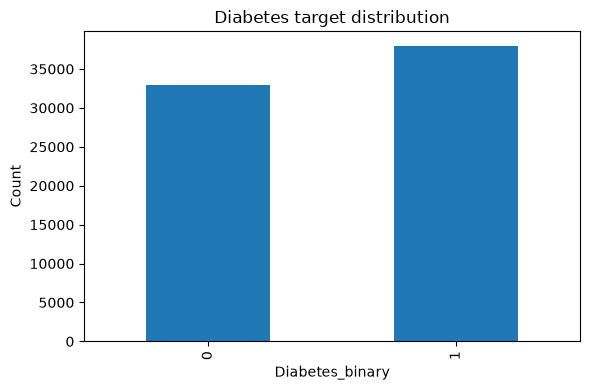

In [46]:
# 5.1 Target distribution
# Cell nay: phan tich phan bo cua target.
# target_counts: so luong tung lop (0/1), sap theo thu tu lop.
target_counts = y.value_counts().sort_index()
# target_percent: ty le % tung lop.
target_percent = y.value_counts(normalize=True).sort_index().mul(100)

# Hien thi bang so luong va % tung lop.
display(pd.DataFrame({"count": target_counts, "percent": target_percent}))

# Tao khung ve kich thuoc 6x4 inch.
plt.figure(figsize=(6, 4))
# Ve bieu do cot cho so luong tung lop.
target_counts.plot(kind="bar")
# Dat tieu de bieu do.
plt.title("Diabetes target distribution")
# Nhan truc X.
plt.xlabel("Diabetes_binary")
# Nhan truc Y.
plt.ylabel("Count")
# Dan bo cuc de nhan khong bi cat.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

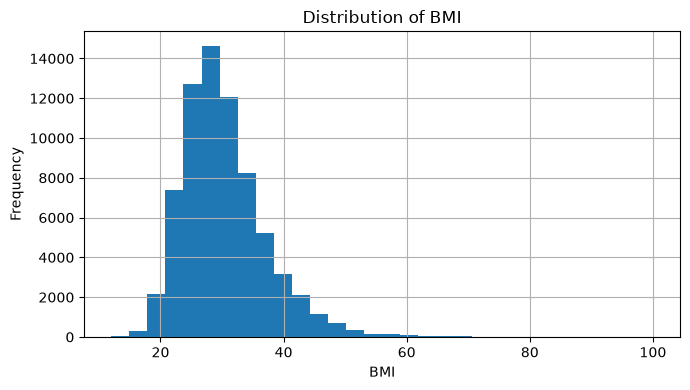

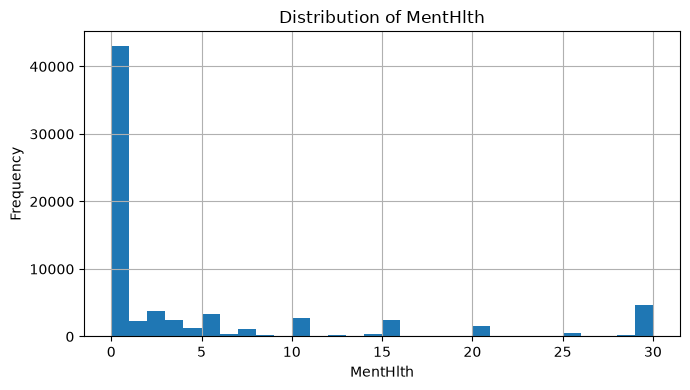

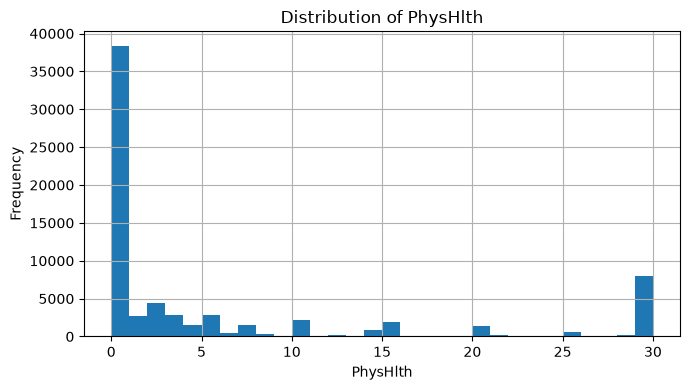

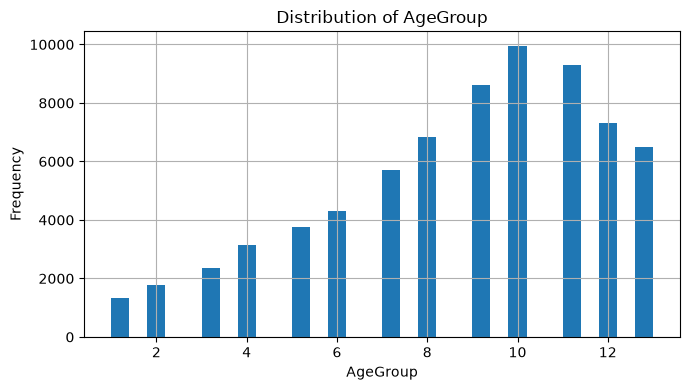

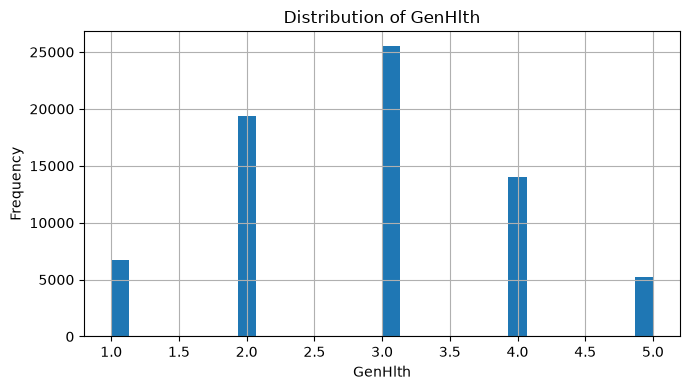

,count,mean,std,min,25%,50%,75%,max
BMI,70841.0,30.225618,7.080539,12.0,25.0,29.0,34.0,100.0
MentHlth,70841.0,4.509267,8.547096,0.0,0.0,0.0,5.0,30.0
PhysHlth,70841.0,5.910758,10.001839,0.0,0.0,0.0,6.0,30.0
AgeGroup,70841.0,8.683545,3.080300,1.0,7.0,9.0,11.0,13.0
GenHlth,70841.0,2.881354,1.063151,1.0,2.0,3.0,4.0,5.0


In [47]:
# 5.2 Important feature distributions
# Cell nay: ve phan bo cua cac feature quan trong.
# Vong lap ve bieu do phan bo cho tung feature.
for col in ["BMI", "MentHlth", "PhysHlth", "AgeGroup", "GenHlth"]:
    # Tao khung ve cho feature hien tai.
    plt.figure(figsize=(7, 4))
    # hist: bieu do tan suat 30 cot; bo NaN truoc khi ve.
    diabetes_clean[col].dropna().hist(bins=30)
    # Tieu de gom ten feature.
    plt.title(f"Distribution of {col}")
    # Truc X: ten feature.
    plt.xlabel(col)
    # Truc Y: tan suat.
    plt.ylabel("Frequency")
    # Dan bo cuc.
    plt.tight_layout()
    # Hien thi bieu do.
    plt.show()

# Bang thong ke mo ta cac feature nay.
display(diabetes_clean[["BMI", "MentHlth", "PhysHlth", "AgeGroup", "GenHlth"]].describe().T)

,feature,target_class,count,mean,median
0,BMI,0,32902,28.309039,27.0
1,BMI,1,37939,31.887741,31.0
2,MentHlth,0,32902,4.105829,0.0
3,MentHlth,1,37939,4.859142,0.0
4,PhysHlth,0,32902,3.862440,0.0
5,PhysHlth,1,37939,7.687129,1.0
6,AgeGroup,0,32902,7.710747,8.0
7,AgeGroup,1,37939,9.527188,10.0
8,GenHlth,0,32902,2.463893,2.0
9,GenHlth,1,37939,3.243391,3.0


<Figure size 600x400 with 0 Axes>

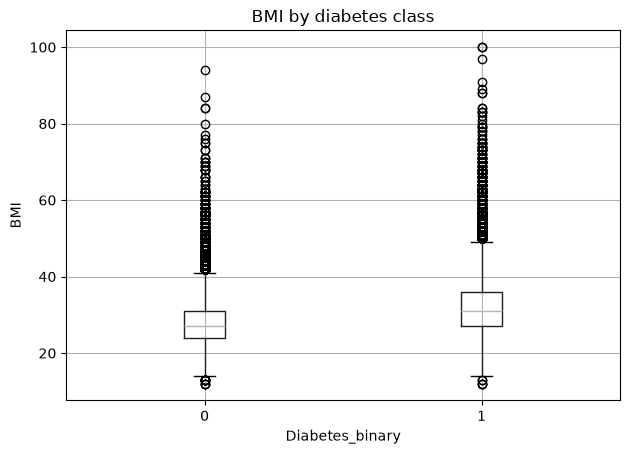

<Figure size 600x400 with 0 Axes>

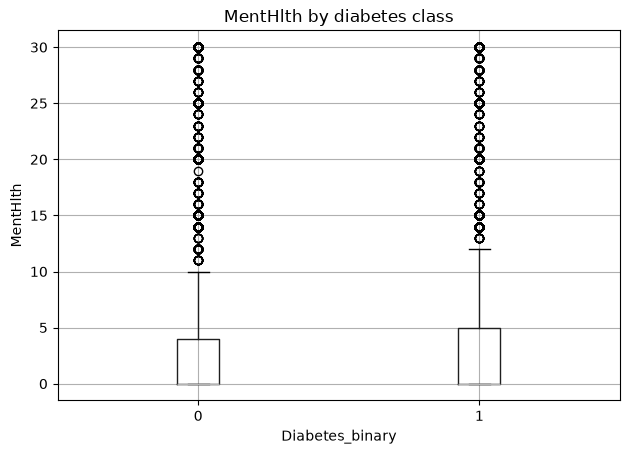

<Figure size 600x400 with 0 Axes>

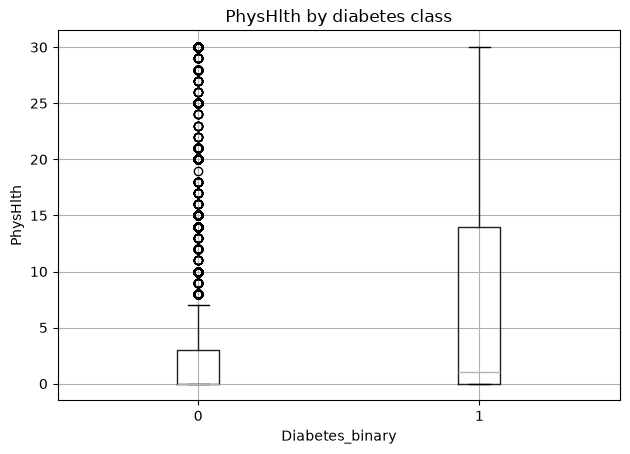

In [48]:
# 5.3 Feature-target relationships
# Cell nay: xem quan he giua feature va target.
# relationship_rows: danh sach luu thong ke feature theo tung lop target.
relationship_rows = []
# Vong lap qua cac feature quan trong.
for col in ["BMI", "MentHlth", "PhysHlth", "AgeGroup", "GenHlth"]:
    # groupby theo target roi tinh count/mean/median cua feature.
    grouped = diabetes_clean.groupby(TARGET)[col].agg(["count", "mean", "median"])
    # Duyet tung lop target trong ket qua nhom.
    for cls, row in grouped.iterrows():
        # Luu mot dong: feature, lop target, count/mean/median.
        relationship_rows.append(
            {
                "feature": col,
                "target_class": int(cls),
                "count": int(row["count"]),
                "mean": row["mean"],
                "median": row["median"],
            }
        )
# Hien thi bang quan he feature-target.
display(pd.DataFrame(relationship_rows))

# Vong lap ve boxplot so sanh feature giua 2 lop.
for col in ["BMI", "MentHlth", "PhysHlth"]:
    # Tao khung ve.
    plt.figure(figsize=(6, 4))
    # boxplot: phan bo feature theo tung lop target.
    diabetes_clean.boxplot(column=col, by=TARGET)
    # Tieu de.
    plt.title(f"{col} by diabetes class")
    # Xoa tieu de tu dong cua pandas de tranh trung.
    plt.suptitle("")
    # Nhan truc X.
    plt.xlabel("Diabetes_binary")
    # Nhan truc Y la ten feature.
    plt.ylabel(col)
    # Dan bo cuc.
    plt.tight_layout()
    # Hien thi boxplot.
    plt.show()

,correlation_with_target
GenHlth,0.365673
HighBP,0.356589
AgeGroup,0.294104
HighChol,0.262328
DiffWalk,0.252423
BMI,0.252076
Income,-0.202685
PhysActivity,-0.200769
HeartDiseaseorAttack,0.193229
PhysHlth,0.190717


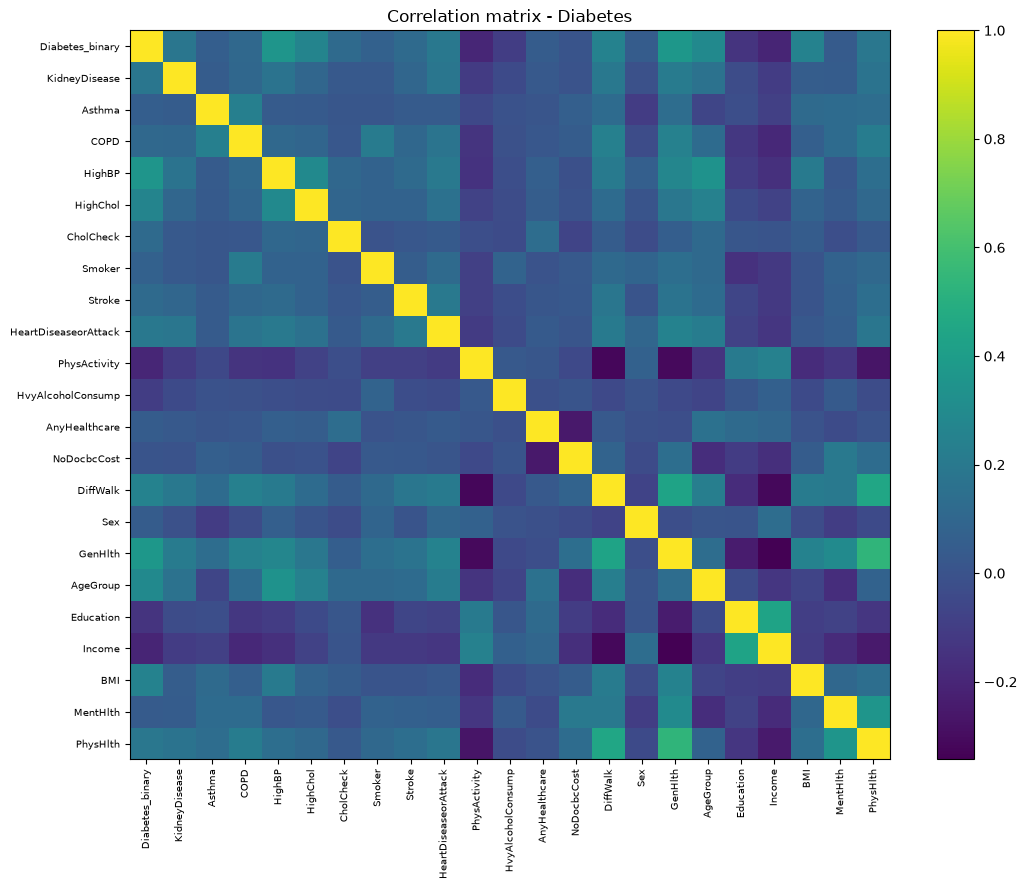

In [49]:
# 5.4 Correlation analysis
# Cell nay: phan tich tuong quan giua cac feature va target.
# corr_columns: danh sach cot dua vao ma tran tuong quan.
corr_columns = [TARGET] + BINARY_FEATURES + ORDINAL_FEATURES + NUMERICAL_FEATURES
# corr(): ma tran he so tuong quan Pearson giua cac cot so.
corr = diabetes_clean[corr_columns].corr(numeric_only=True)

# Lay cot tuong quan voi target, bo chinh target, sap theo tri tuyet doi giam dan.
target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
# Hien thi bang tuong quan voi target.
display(target_corr.to_frame("correlation_with_target"))

# Tao khung ve lon cho ma tran tuong quan.
plt.figure(figsize=(11, 9))
# imshow: hien thi ma tran duoi dang anh mau.
plt.imshow(corr, aspect="auto")
# Them thanh mau chu thich gia tri tuong quan.
plt.colorbar()
# Dat nhan cot o truc X, xoay 90 do cho khoi chong.
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
# Dat nhan hang o truc Y.
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
# Tieu de.
plt.title("Correlation matrix - Diabetes")
# Dan bo cuc.
plt.tight_layout()
# Hien thi ma tran tuong quan.
plt.show()

# PART VI - TRAIN, VALIDATION, AND TEST DATA

Sử dụng tỷ lệ **70% / 15% / 15%**, `stratify=y` và `random_state=42`.

Validation dùng để so sánh/chọn mô hình. Test được giữ độc lập và chỉ dùng một lần sau khi đã chọn mô hình cuối.

In [50]:
# 6.1 Split 70/15/15
# Cell nay: chia du lieu thanh train (70%), validation (15%) va test (15%).
# train_test_split: ham chia du lieu ngau nhien cua sklearn.
from sklearn.model_selection import train_test_split

# Chia lan 1: 70% train, 30% con lai (tam) de chia tiep.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    # 30% du lieu duoc giu lai cho buoc chia thu hai.
    test_size=0.30,
    # Co dinh seed de lan chay nao cung chia giong nhau.
    random_state=RANDOM_SEED,
    # stratify: giu ty le 2 lop target giong nhau giua train va phan tam.
    stratify=y,
)

# Chia lan 2: phan tam (30%) thanh validation (15%) va test (15%).
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    # Lay 50% cua phan tam lam test - tuc 15% toan bo du lieu.
    test_size=0.50,
    random_state=RANDOM_SEED,
    # Giu can bang lop target trong validation/test.
    stratify=y_temp,
)

# Tao bang tom tat 3 tap: so dong, ty le % va ty le duong tinh.
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "percent": [
            len(X_train) / len(X) * 100,
            len(X_val) / len(X) * 100,
            len(X_test) / len(X) * 100,
        ],
        "positive_rate_percent": [
            y_train.mean() * 100,
            y_val.mean() * 100,
            y_test.mean() * 100,
        ],
    }
)
# Hien thi bang chia du lieu.
display(split_summary)

,split,rows,percent,positive_rate_percent
0,train,49588,69.999012,53.555296
1,validation,10626,14.999788,53.557312
2,test,10627,15.001200,53.552273


In [51]:
# 6.2 Fit representation ONLY on train and report exact model-input representation
# Cell nay: fit preprocessing CHI tren train roi transform ca 3 tap de kiem tra shape dau vao.
# clone: tao ban sao chua fit cua preprocessor (khong dung chung tham so da hoc).
from sklearn.base import clone

# Sao chep preprocessor goc de fit rieng (tranh anh huong pipeline khac).
representation_preprocessor = clone(preprocessor)
# fit tren X_train: hoc vi tri cot, gia tri impute va tham so scaler.
representation_preprocessor.fit(X_train, y_train)

# transform: bien doi du lieu train thanh ma tran so.
X_train_num = representation_preprocessor.transform(X_train)
# Transform validation bang preprocessor DA fit tren train (khong hoc lai).
X_val_num = representation_preprocessor.transform(X_val)
# Transform test tuong tu - tranh data leakage.
X_test_num = representation_preprocessor.transform(X_test)

# Lay danh sach ten feature sau khi bien doi.
feature_names = representation_preprocessor.get_feature_names_out()

# Tao bang so sanh shape du lieu tho va shape dau vao model.
representation_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "raw_shape": [X_train.shape, X_val.shape, X_test.shape],
        "model_input_shape": [X_train_num.shape, X_val_num.shape, X_test_num.shape],
        "dtype": [
            str(X_train_num.dtype),
            str(X_val_num.dtype),
            str(X_test_num.dtype),
        ],
    }
)
# Hien thi bang tom tat bieu dien.
display(representation_summary)

# In so chieu feature cuoi cung.
print("Final feature dimension d =", len(feature_names))
# In tieu de danh sach 22 feature dau tien.
print("First 22 feature names:")
# In toan bo ten feature.
print(feature_names.tolist())

# In tieu de: mot dong du lieu tho mau.
print("\nOne raw observation:")
# Hien thi dong dau tien cua X_train (du lieu tho).
display(X_train.head(1))

# In tieu de: vector so tuong ung sau preprocessing.
print("\nCorresponding numerical feature vector:")
# Lay dong dau tien cua ma tran da bien doi va chuyen thanh mang 1 chieu.
first_vector = np.asarray(X_train_num[0]).reshape(-1)
# Hien thi tung feature kem gia tri so tuong ung.
display(pd.DataFrame({"feature": feature_names, "value": first_vector}))

,split,raw_shape,model_input_shape,dtype
0,train,"(49588, 22)","(49588, 22)",float64
1,validation,"(10626, 22)","(10626, 22)",float64
2,test,"(10627, 22)","(10627, 22)",float64


Final feature dimension d = 22
First 22 feature names:
['KidneyDisease', 'Asthma', 'COPD', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'AgeGroup', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth']

One raw observation:


,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
13655,0.0,0.0,0.0,1.0,0.0,0.0,45.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,5.0,8.0



Corresponding numerical feature vector:


,feature,value
0,KidneyDisease,-0.313636
1,Asthma,-0.451277
2,COPD,-0.343152
3,HighBP,-1.157271
4,HighChol,-1.057041
5,CholCheck,0.149565
6,Smoker,-0.866382
7,Stroke,-0.264354
8,HeartDiseaseorAttack,-0.407542
9,PhysActivity,0.646165


In [52]:
# Part IV evidence — Raw representation -> Clean representation

sample_index = X_train.index[0]

print("CLEAN REPRESENTATION")
display(diabetes_clean.loc[[sample_index]])

print("\nMODEL FEATURES BEFORE NUMERICAL TRANSFORMATION")
display(X_train.loc[[sample_index]])

CLEAN REPRESENTATION


,Diabetes_binary,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
13655,0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,5.0,8.0



MODEL FEATURES BEFORE NUMERICAL TRANSFORMATION


,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
13655,0.0,0.0,0.0,1.0,0.0,0.0,45.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,5.0,8.0


In [53]:
# Part IV evidence — Numerical representation matrix

X_train_matrix_preview = pd.DataFrame(
    np.asarray(X_train_num[:5]),
    columns=feature_names,
    index=X_train.index[:5],
)

print("NUMERICAL REPRESENTATION — first 5 rows")
print("Matrix shape:", X_train_num.shape)
print("Matrix dtype:", np.asarray(X_train_num).dtype)

display(X_train_matrix_preview)

NUMERICAL REPRESENTATION — first 5 rows
Matrix shape: (49588, 22)
Matrix dtype: float64


,KidneyDisease,Asthma,COPD,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,NoDocbcCost,DiffWalk,Sex,GenHlth,AgeGroup,Education,Income,BMI,MentHlth,PhysHlth
13655,-0.313636,-0.451277,-0.343152,-1.157271,-1.057041,0.149565,-0.866382,-0.264354,-0.407542,0.646165,...,-0.289025,-0.555298,0.995533,0.112943,-2.489957,-0.052140,0.502505,2.084823,-0.527209,-0.591088
62463,-0.313636,-0.451277,-0.343152,-1.157271,0.946037,0.149565,-0.866382,-0.264354,-0.407542,-1.547593,...,-0.289025,-0.555298,-1.004487,0.112943,0.104776,-0.052140,0.089322,-1.021732,2.994699,-0.591088
51524,-0.313636,-0.451277,-0.343152,-1.157271,0.946037,0.149565,-0.866382,-0.264354,-0.407542,0.646165,...,-0.289025,-0.555298,-1.004487,-0.829126,0.429117,-1.071255,-0.323860,-0.880525,-0.527209,-0.591088
2688,-0.313636,2.215935,-0.343152,-1.157271,-1.057041,0.149565,-0.866382,-0.264354,-0.407542,0.646165,...,-0.289025,-0.555298,-1.004487,0.112943,-0.868249,0.966976,0.089322,-0.598111,-0.527209,-0.591088
47429,-0.313636,-0.451277,-0.343152,0.864101,0.946037,0.149565,1.154225,3.782812,-0.407542,-1.547593,...,3.459908,1.800835,-1.004487,1.055011,0.429117,-0.052140,0.089322,2.226030,-0.527209,1.411356


In [54]:
# Part IV evidence — Categorical representation for Diabetes

categorical_demo_cols = [
    "HighBP",
    "HighChol",
    "Smoker",
    "Sex",
    "GenHlth",
    "AgeGroup",
    "Education",
    "Income",
]

print("CATEGORICAL / ORDINAL REPRESENTATION BEFORE MODEL INPUT")
display(X_train[categorical_demo_cols].head(5))

CATEGORICAL / ORDINAL REPRESENTATION BEFORE MODEL INPUT


,HighBP,HighChol,Smoker,Sex,GenHlth,AgeGroup,Education,Income
13655,0.0,0.0,0.0,1.0,3.0,1.0,5.0,8.0
62463,0.0,1.0,0.0,0.0,3.0,9.0,5.0,7.0
51524,0.0,1.0,0.0,0.0,2.0,10.0,4.0,6.0
2688,0.0,0.0,0.0,0.0,3.0,6.0,6.0,7.0
47429,1.0,1.0,1.0,0.0,4.0,10.0,5.0,7.0


In [55]:
transformed_df = pd.DataFrame(
    np.asarray(X_train_num[:5]),
    columns=feature_names,
)

display(
    transformed_df[
        [
            c
            for c in feature_names
            if any(
                key in c
                for key in [
                    "HighBP",
                    "HighChol",
                    "Smoker",
                    "Sex",
                    "GenHlth",
                    "AgeGroup",
                    "Education",
                    "Income",
                ]
            )
        ]
    ]
)

,HighBP,HighChol,Smoker,Sex,GenHlth,AgeGroup,Education,Income
0,-1.157271,-1.057041,-0.866382,0.995533,0.112943,-2.489957,-0.052140,0.502505
1,-1.157271,0.946037,-0.866382,-1.004487,0.112943,0.104776,-0.052140,0.089322
2,-1.157271,0.946037,-0.866382,-1.004487,-0.829126,0.429117,-1.071255,-0.323860
3,-1.157271,-1.057041,-0.866382,-1.004487,0.112943,-0.868249,0.966976,0.089322
4,0.864101,0.946037,1.154225,-1.004487,1.055011,0.429117,-0.052140,0.089322


In [56]:
# 6.3 Leakage check / preprocessing statistics
# Cell nay: kiem tra nhanh rang khong co data leakage va xem dai gia tri dau vao model.
# In khang dinh imputer/scaler chi fit tren train.
print("Imputer/scaler were fit on TRAIN only.")
# In khang dinh validation/test chi transform bang preprocessor da fit tren train.
print("Validation/test were transformed with the already-fitted train preprocessor.")

# Chuyen ma tran train thanh mang numpy de tinh thong ke.
train_array = np.asarray(X_train_num)
# In gia tri nho nhat va lon nhat trong du lieu train.
print("Train numerical range:", float(np.nanmin(train_array)), "to", float(np.nanmax(train_array)))
# In trung binh toan bo ma tran train.
print("Train mean (overall):", float(np.nanmean(train_array)))
# In do lech chuan toan bo ma tran train.
print("Train std (overall):", float(np.nanstd(train_array)))

Imputer/scaler were fit on TRAIN only.
Validation/test were transformed with the already-fitted train preprocessor.
Train numerical range: -6.686047098731179 to 9.85121155867053
Train mean (overall): 3.691652146677942e-17
Train std (overall): 1.0


# PART VII - MODEL DEVELOPMENT

So sánh 5 mô hình được Assignment khuyến nghị cho Diabetes:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. KNN

Mỗi mô hình nhận **cùng một preprocessing pipeline** để bảo đảm so sánh công bằng.

In [57]:
# 7.1 Define models and evaluation function
# Cell nay: dinh nghia 5 model phan loai va ham danh gia chung.
# sklearn.metrics: cac ham do chat luong du doan.
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# LogisticRegression: mo hinh hoi quy logistic.
from sklearn.linear_model import LogisticRegression

# DecisionTreeClassifier: cay quyet dinh.
from sklearn.tree import DecisionTreeClassifier

# RandomForestClassifier: rung ngau nhien (to hop nhieu cay).
from sklearn.ensemble import RandomForestClassifier

# SVC: may vector ho tro cho phan loai.
from sklearn.svm import SVC

# KNeighborsClassifier: K-lang gieng gan nhat.
from sklearn.neighbors import KNeighborsClassifier

# MODELS: dictionary chua 5 model voi tham so da chon san.
MODELS = {
    # Logistic Regression: tang max_iter de hoi tu, co dinh random_state.
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_SEED,
    ),
    # Decision Tree: max_depth=None (khong gioi han), min_samples_leaf=5 tranh overfit.
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
    ),
    # Random Forest: 200 cay, min_samples_leaf=2, n_jobs=-1 dung moi CPU.
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    # SVM: kernel RBF, C=1.0, gamma tu dong theo du lieu.
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        cache_size=2048,
    ),
    # KNN: 15 lang gieng, trong so theo khoang cach.
    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1,
    ),
}


# Ham danh gia mot model tren tap du lieu: tra ve metrics, nhan du doan va diem so.
def classifier_scores(estimator, X_eval, y_eval):
    # Du doan nhan cho tung dong.
    pred = estimator.predict(X_eval)

    # Neu model co ham xac suat (hau het model), dung xac suat lop 1 lam diem xep hang.
    if hasattr(estimator, "predict_proba"):
        # predict_proba tra ve [P(0), P(1)]; lay cot 1 la xac suat lop duong.
        score = estimator.predict_proba(X_eval)[:, 1]
    # Neu khong, dung decision_function (vi du SVM) lam diem.
    elif hasattr(estimator, "decision_function"):
        # decision_function: khoang cach toi sieu phang phan chia.
        score = estimator.decision_function(X_eval)
    # Truong hop con lai: dung chinh nhan du doan lam diem.
    else:
        # Gan diem bang nhan du doan.
        score = pred

    # Ma tran nham lan: dem TN/FP/FN/TP.
    cm = confusion_matrix(y_eval, pred)
    # ravel: trai ma tran 2x2 thanh 4 so theo thu tu TN, FP, FN, TP.
    tn, fp, fn, tp = cm.ravel()

    # Tra ve 3 thu: dictionary metrics, nhan du doan va diem so.
    return (
        {
            # Accuracy: ty le du doan dung.
            "Accuracy": accuracy_score(y_eval, pred),
            # Precision: trong so du doan duong, bao nhieu dung (zero_division=0 tranh loi chia 0).
            "Precision": precision_score(y_eval, pred, zero_division=0),
            # Recall: trong so thuc duong, bat duoc bao nhieu.
            "Recall": recall_score(y_eval, pred, zero_division=0),
            # F1: trung binh dieu hoa cua Precision va Recall.
            "F1": f1_score(y_eval, pred, zero_division=0),
            # ROC-AUC: kha nang xep hang 2 lop tren moi nguong.
            "ROC_AUC": roc_auc_score(y_eval, score),
            # TN/FP/FN/TP: cac o cua ma tran nham lan.
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
        },
        # Tra ve nhan du doan.
        pred,
        # Tra ve diem so de ve ROC.
        score,
    )

In [58]:
# 7.2 Train 5 models on train; evaluate on validation
# Cell nay: huan luyen 5 model tren train va danh gia tren validation.
# fitted_models: luu pipeline da fit cua tung model.
fitted_models = {}
# Luu nhan du doan tren validation cua tung model.
validation_predictions = {}
# Luu diem so tho (xac suat/decision) tren validation.
validation_scores_raw = {}
# Danh sach tich luy metrics cua tung model.
result_rows = []

# Vong lap qua tung model.
for name, model in MODELS.items():
    # Moi model duoc boc trong Pipeline gom preprocessor + model de dam bao cung tien xu ly.
    pipe = Pipeline(
        steps=[
            # Buoc 1: preprocessor (ban sao chua fit) - impute va chuan hoa.
            ("preprocessor", clone(preprocessor)),
            # Buoc 2: model phan loai (ban sao).
            ("model", clone(model)),
        ]
    )

    # Ghi thoi diem bat dau huan luyen.
    start = time.perf_counter()
    # Fit toan bo pipeline tren train.
    pipe.fit(X_train, y_train)
    # Tinh thoi gian huan luyen.
    train_seconds = time.perf_counter() - start

    # Danh gia pipeline tren validation.
    scores, pred, score = classifier_scores(pipe, X_val, y_val)
    # Gan ten model vao bang metrics.
    scores["Model"] = name
    # Gan thoi gian huan luyen.
    scores["Train_seconds"] = train_seconds

    # Luu pipeline da fit.
    fitted_models[name] = pipe
    # Luu nhan du doan.
    validation_predictions[name] = pred
    # Luu diem so.
    validation_scores_raw[name] = score
    # Them metrics vao danh sach.
    result_rows.append(scores)

# Gop ket qua thanh bang, xep hang theo F1, ROC-AUC, Recall giam dan.
validation_results = (
    pd.DataFrame(result_rows)
    .set_index("Model")
    .sort_values(["F1", "ROC_AUC", "Recall"], ascending=False)
)

# Hien thi bang so sanh 5 model tren validation.
display(validation_results)

,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP,Train_seconds
Model,,,,,,,,,,
SVM,0.742707,0.727707,0.830258,0.775607,0.806797,3167,1768,966,4725,81.169710
Random Forest,0.743365,0.734494,0.815674,0.772958,0.811057,3257,1678,1049,4642,1.531647
Logistic Regression,0.744024,0.745172,0.793358,0.768511,0.816913,3391,1544,1176,4515,0.165594
KNN,0.722567,0.718705,0.791952,0.753553,0.777857,3171,1764,1184,4507,0.060493
Decision Tree,0.671560,0.696553,0.685293,0.690877,0.727654,3236,1699,1791,3900,0.199912


# PART VIII - MODEL EVALUATION

Báo cáo `Accuracy`, `Precision`, `Recall`, `F1-score`, `ROC-AUC` và confusion matrix.

Trong bối cảnh dự đoán tiểu đường:
- `Recall` cho biết tỷ lệ người thực sự thuộc lớp diabetes được phát hiện;
- `Precision` cho biết trong các trường hợp model dự đoán diabetes, bao nhiêu trường hợp là đúng;
- `F1` cân bằng Precision và Recall;
- `ROC-AUC` đo khả năng xếp hạng hai lớp trên nhiều threshold.

In [59]:
# 8.1 Validation confusion matrices as a compact table
# Cell nay: gom ma tran nham lan cua 5 model thanh mot bang gon.
# cm_rows: danh sach luu TN/FP/FN/TP cua tung model.
cm_rows = []
# Duyet tung model theo thu tu xep hang.
for name in validation_results.index:
    # Lay nhan du doan validation cua model.
    pred = validation_predictions[name]
    # Tinh ma tran nham lan roi tach 4 gia tri.
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    # Luu mot dong ket qua cho model.
    cm_rows.append(
        {
            "Model": name,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
        }
    )

# Hien thi bang ma tran nham lan, dung ten model lam chi so.
display(pd.DataFrame(cm_rows).set_index("Model"))

,TN,FP,FN,TP
Model,,,,
SVM,3167,1768,966,4725
Random Forest,3257,1678,1049,4642
Logistic Regression,3391,1544,1176,4515
KNN,3171,1764,1184,4507
Decision Tree,3236,1699,1791,3900


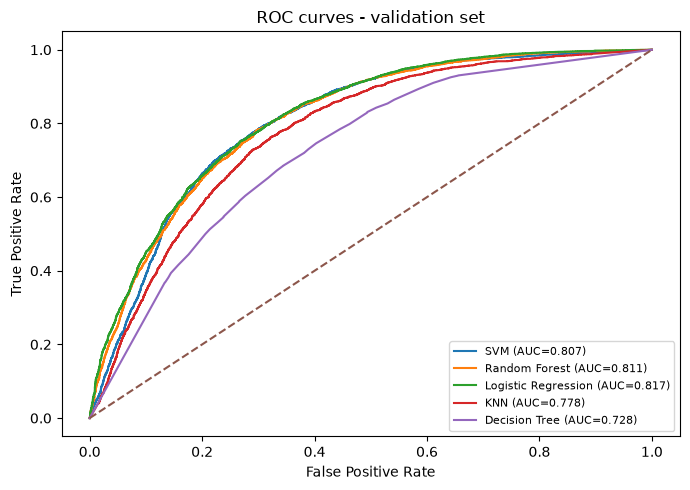

In [60]:
# 8.2 ROC curves on validation set
# Cell nay: ve duong cong ROC tren tap validation.
# roc_curve: tinh cap (FPR, TPR) tai cac nguong khac nhau.
from sklearn.metrics import roc_curve

# Tao khung ve.
plt.figure(figsize=(7, 5))
# Ve duong ROC cho tung model.
for name in validation_results.index:
    # Tinh FPR (truc X) va TPR (truc Y) tu diem so cua model.
    fpr, tpr, _ = roc_curve(y_val, validation_scores_raw[name])
    # Lay gia tri AUC da tinh tu truoc.
    auc_value = validation_results.loc[name, "ROC_AUC"]
    # Ve duong ROC kem ten model va AUC.
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

# Duong cheo tham chieu: model khong tot hon doan ngau nhien.
plt.plot([0, 1], [0, 1], linestyle="--")
# Nhan truc X: ty le duong tinh gia.
plt.xlabel("False Positive Rate")
# Nhan truc Y: ty le duong tinh that.
plt.ylabel("True Positive Rate")
# Tieu de.
plt.title("ROC curves - validation set")
# Chu thich ten model.
plt.legend(fontsize=8)
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

# PART IX - MODEL COMPARISON AND FINAL MODEL SELECTION

Quy tắc chọn trong notebook:
- ưu tiên **F1** trên validation;
- dùng `ROC-AUC` và `Recall` làm tiêu chí phụ khi F1 gần nhau;
- sau khi chọn xong mới refit trên `train + validation` và đánh giá đúng **một lần** trên test.

In [61]:
# 9.1 Select best validation model and refit on train+validation
# Cell nay: chon model tot nhat theo validation roi refit tren train + validation.
# Tieu chi chinh de chon model la F1.
PRIMARY_METRIC = "F1"
# Lay ten model dung dau bang xep hang (F1 cao nhat).
best_model_name = validation_results.index[0]

# In model duoc chon.
print("Selected model based on validation ranking:", best_model_name)
# Hien thi metrics validation cua model duoc chon.
display(validation_results.loc[[best_model_name]])

# Gop train va validation thanh tap trainval theo hang.
X_trainval = pd.concat([X_train, X_val], axis=0)
# Gop nhan tuong ung.
y_trainval = pd.concat([y_train, y_val], axis=0)

# Tao pipeline cuoi cung cho model duoc chon.
final_pipeline = Pipeline(
    steps=[
        # Buoc 1: preprocessor moi (fit lai tren trainval).
        ("preprocessor", clone(preprocessor)),
        # Buoc 2: model duoc chon (ban sao chua fit).
        ("model", clone(MODELS[best_model_name])),
    ]
)

# Ghi thoi diem bat dau refit.
start = time.perf_counter()
# Refit pipeline tren toan bo train + validation.
final_pipeline.fit(X_trainval, y_trainval)
# Tinh thoi gian refit.
final_refit_seconds = time.perf_counter() - start

# Danh gia model cuoi DUNG MOT LAN tren test.
test_scores, y_test_pred, y_test_score = classifier_scores(
    final_pipeline,
    X_test,
    y_test,
)

# Tao bang ket qua test gom metrics va thoi gian refit.
test_result = pd.DataFrame(
    [{**test_scores, "Model": best_model_name, "Refit_seconds": final_refit_seconds}]
).set_index("Model")

# Hien thi ket qua test.
display(test_result)

Selected model based on validation ranking: SVM


,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP,Train_seconds
Model,,,,,,,,,,
SVM,0.742707,0.727707,0.830258,0.775607,0.806797,3167,1768,966,4725,81.16971


,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP,Refit_seconds
Model,,,,,,,,,,
SVM,0.744895,0.728668,0.8343,0.777914,0.804772,3168,1768,943,4748,140.739351


              precision    recall  f1-score   support

           0     0.7706    0.6418    0.7003      4936
           1     0.7287    0.8343    0.7779      5691

    accuracy                         0.7449     10627
   macro avg     0.7496    0.7381    0.7391     10627
weighted avg     0.7482    0.7449    0.7419     10627



<Figure size 500x500 with 0 Axes>

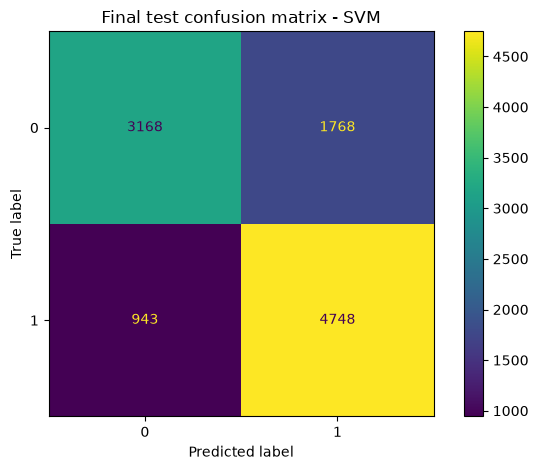

In [62]:
# 9.2 Final confusion matrix and classification report
# Cell nay: bao cao phan loai chi tiet va ma tran nham lan cuoi cung tren test.
# classification_report: bang Precision/Recall/F1 theo tung lop; ConfusionMatrixDisplay: ve ma tran.
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# In bao cao phan loai voi 4 chu so thap phan.
print(classification_report(y_test, y_test_pred, digits=4))

# Tao khung ve vuong.
plt.figure(figsize=(5, 5))
# Ve ma tran nham lan tu nhan that va nhan du doan.
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
# Tieu de gom ten model.
plt.title(f"Final test confusion matrix - {best_model_name}")
# Dan bo cuc.
plt.tight_layout()
# Hien thi bieu do.
plt.show()

In [63]:
# 9.3 Error analysis
# Cell nay: phan tich loi du doan tren test (False Negative/False Positive).
# error_df: ban sao X_test de gan them cot nhan that va nhan du doan.
error_df = X_test.copy()
# Cot actual: nhan that te.
error_df["actual"] = y_test.values
# Cot predicted: nhan du doan.
error_df["predicted"] = y_test_pred
# np.select: gan loai loi theo tung dieu kien.
error_df["error_type"] = np.select(
    [
        # Dieu kien 1: that la 1 nhung du doan 0 -> False Negative.
        (error_df["actual"] == 1) & (error_df["predicted"] == 0),
        # Dieu kien 2: that la 0 nhung du doan 1 -> False Positive.
        (error_df["actual"] == 0) & (error_df["predicted"] == 1),
    ],
    # Nhan tuong ung 2 dieu kien tren.
    ["False Negative", "False Positive"],
    # Cac truong hop con lai la du doan dung.
    default="Correct",
)

# Dem so luong tung loai loi.
display(error_df["error_type"].value_counts().to_frame("count"))

# In tieu de: vi du False Negative.
print("\nFalse Negative examples:")
# Hien thi 10 dong bo sot nguoi benh (benh nhung du doan khoe).
display(error_df.loc[error_df["error_type"] == "False Negative"].head(10))

# In tieu de: vi du False Positive.
print("\nFalse Positive examples:")
# Hien thi 10 dong bao nham nguoi khoe thanh benh.
display(error_df.loc[error_df["error_type"] == "False Positive"].head(10))

,count
error_type,
Correct,7916
False Positive,1768
False Negative,943



False Negative examples:


,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,...,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income,actual,predicted,error_type
56959,0.0,0.0,1.0,1.0,0.0,0.0,27.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,8.0,6.0,11.0,1,0,False Negative
70633,0.0,0.0,1.0,1.0,0.0,0.0,25.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,6.0,6.0,10.0,1,0,False Negative
50850,0.0,0.0,0.0,1.0,0.0,0.0,32.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,6.0,8.0,1,0,False Negative
57560,0.0,0.0,0.0,1.0,0.0,0.0,32.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,5.0,6.0,10.0,1,0,False Negative
53929,0.0,0.0,0.0,1.0,0.0,0.0,33.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,11.0,5.0,7.0,1,0,False Negative
42484,0.0,0.0,0.0,1.0,0.0,0.0,37.0,0.0,0.0,0.0,...,4.0,3.0,0.0,1.0,4.0,6.0,9.0,1,0,False Negative
70712,0.0,0.0,1.0,1.0,0.0,0.0,28.0,0.0,0.0,0.0,...,30.0,6.0,0.0,0.0,5.0,5.0,7.0,1,0,False Negative
63379,0.0,0.0,0.0,1.0,0.0,0.0,31.0,1.0,0.0,0.0,...,15.0,0.0,0.0,0.0,2.0,5.0,7.0,1,0,False Negative
64229,0.0,0.0,0.0,1.0,0.0,0.0,27.0,0.0,0.0,0.0,...,30.0,0.0,0.0,0.0,5.0,6.0,6.0,1,0,False Negative
50733,0.0,1.0,1.0,1.0,0.0,0.0,19.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,7.0,4.0,6.0,1,0,False Negative



False Positive examples:


,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,...,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income,actual,predicted,error_type
24435,0.0,1.0,0.0,1.0,1.0,0.0,24.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,9.0,3.0,3.0,0,1,False Positive
302,0.0,1.0,1.0,1.0,0.0,0.0,26.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,10.0,5.0,7.0,0,1,False Positive
32107,0.0,1.0,0.0,1.0,1.0,0.0,32.0,0.0,0.0,0.0,...,0.0,2.0,1.0,0.0,11.0,6.0,8.0,0,1,False Positive
1821,0.0,1.0,1.0,1.0,0.0,0.0,48.0,1.0,0.0,0.0,...,0.0,2.0,0.0,0.0,5.0,5.0,9.0,0,1,False Positive
14136,0.0,0.0,1.0,1.0,0.0,0.0,32.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,10.0,6.0,5.0,0,1,False Positive
6768,0.0,1.0,0.0,1.0,0.0,0.0,27.0,0.0,1.0,0.0,...,0.0,30.0,1.0,1.0,12.0,6.0,7.0,0,1,False Positive
21095,0.0,0.0,1.0,1.0,0.0,0.0,32.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,10.0,6.0,6.0,0,1,False Positive
831,1.0,0.0,1.0,1.0,0.0,0.0,23.0,0.0,0.0,1.0,...,3.0,10.0,1.0,0.0,10.0,5.0,5.0,0,1,False Positive
22239,0.0,1.0,1.0,1.0,0.0,0.0,26.0,0.0,0.0,1.0,...,2.0,2.0,0.0,1.0,7.0,5.0,11.0,0,1,False Positive
24726,1.0,1.0,1.0,1.0,0.0,0.0,31.0,0.0,1.0,0.0,...,0.0,30.0,1.0,0.0,12.0,5.0,3.0,0,1,False Positive


# PART X - MODEL PERSISTENCE AND INFERENCE TEST

Lưu **toàn bộ pipeline** (preprocessing + feature transformation + trained model) để inference dùng đúng logic đã fit từ dữ liệu huấn luyện.

In [64]:
# 10.1 Persist final pipeline, fitted preprocessor, fitted model and metadata
# Cell nay: luu pipeline cuoi, preprocessor, model va metadata ra thu muc model.
# Duong dan thu muc chua model (tuong doi tu thu muc notebook).
MODEL_DIR = Path("../model")
# Tao thu muc neu chua ton tai (parents=True tao ca thu muc cha).
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Duong dan file luu toan bo pipeline.
PIPELINE_PATH = MODEL_DIR / "diabetes_pipeline.joblib"
# Duong dan file luu rieng preprocessor.
PREPROCESSOR_PATH = MODEL_DIR / "diabetes_preprocessor.joblib"
# Duong dan file luu rieng model.
MODEL_PATH = MODEL_DIR / "diabetes_model.joblib"
# Duong dan file metadata (thong tin mo ta pipeline).
METADATA_PATH = MODEL_DIR / "diabetes_metadata.json"

# Lay preprocessor da fit ben trong pipeline cuoi.
final_preprocessor = final_pipeline.named_steps["preprocessor"]
# Lay model da fit ben trong pipeline cuoi.
final_model = final_pipeline.named_steps["model"]

# joblib.dump: ghi pipeline ra dia de dung lai sau.
joblib.dump(final_pipeline, PIPELINE_PATH)
# Ghi rieng preprocessor.
joblib.dump(final_preprocessor, PREPROCESSOR_PATH)
# Ghi rieng model.
joblib.dump(final_model, MODEL_PATH)

# Lay ten feature cuoi cung sau preprocessing.
final_feature_names = final_preprocessor.get_feature_names_out()
# Bien doi X_test thanh ma tran dau vao model (de ghi shape vao metadata).
final_test_input = final_preprocessor.transform(X_test)

# Tao dictionary metadata luu thong tin pipeline va ket qua.
metadata = {
    # Ten ung dung.
    "application": "Diabetes Prediction",
    "primary_dataset": DISPLAY_NAMES[PRIMARY_KEY],
    "target": TARGET,
    "random_seed": RANDOM_SEED,
    # Kich thuoc du lieu tho va du lieu sach.
    "raw_dataframe_shape": list(diabetes_raw.shape),
    "clean_dataframe_shape": list(diabetes_clean.shape),
    "raw_feature_count": int(X.shape[1]),
    # So chieu feature sau preprocessing.
    "final_feature_dimension": int(len(final_feature_names)),
    "final_test_model_input_shape": list(final_test_input.shape),
    "feature_names": final_feature_names.tolist(),
    # Ten model duoc chon.
    "selected_model": best_model_name,
    "validation_primary_metric": PRIMARY_METRIC,
    # Cac metrics tren test cua model cuoi.
    "test_metrics": {
        k: float(v)
        for k, v in test_scores.items()
        if k in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
    },
    "cleaning_rules": {
        "duplicates": "drop exact duplicate rows",
        "yes_no_12": "1->1, 2->0, other codes->missing",
        "binary_01": "values outside {0,1}->missing",
        "ordinal_ranges": ORDINAL_RANGES,
        "continuous_ranges": CONTINUOUS_RANGES,
        "outliers": "IQR used for analysis only; no automatic IQR deletion",
    },
}

# Mo file metadata de ghi (encoding UTF-8).
with open(METADATA_PATH, "w", encoding="utf-8") as f:
    # Ghi metadata dang JSON, giu nguyen ky tu Unicode, thut le 2 khoang trang.
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# In duong dan tuyet doi file pipeline.
print("Saved full pipeline:", PIPELINE_PATH.resolve())
# In duong dan file preprocessor.
print("Saved preprocessor:", PREPROCESSOR_PATH.resolve())
# In duong dan file model.
print("Saved fitted model:", MODEL_PATH.resolve())
# In duong dan file metadata.
print("Saved metadata:", METADATA_PATH.resolve())
# In shape dau vao model tren test.
print("Final model-input shape on test:", final_test_input.shape)
# In so chieu feature cuoi.
print("Final feature dimension d:", len(final_feature_names))

Saved full pipeline: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\diabetes\model\diabetes_pipeline.joblib
Saved preprocessor: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\diabetes\model\diabetes_preprocessor.joblib
Saved fitted model: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\diabetes\model\diabetes_model.joblib
Saved metadata: C:\Users\Dat Nguyen\Desktop\LEARN\PTCHTTM\Phat_trien_cac_he_thong_thong_minh_BE\diabetes\model\diabetes_metadata.json
Final model-input shape on test: (10627, 22)
Final feature dimension d: 22


In [65]:
# 10.2 Reload and inference consistency test
# Cell nay: kiem tra tinh nhat quan - nap lai pipeline tu dia roi so sanh du doan.
# joblib.load: nap pipeline da luu.
reloaded_pipeline = joblib.load(PIPELINE_PATH)

# Lay 5 dong dau cua X_test lam mau kiem tra.
sample_input = X_test.head(5).copy()
# Du doan truoc khi luu.
pred_before = final_pipeline.predict(sample_input)
# Du doan sau khi nap lai.
pred_after = reloaded_pipeline.predict(sample_input)

# In tieu de: du lieu dau vao mau.
print("Sample raw input:")
# Hien thi mau du lieu tho.
display(sample_input)

# In du doan truoc khi luu.
print("Prediction before save:", pred_before.tolist())
# In du doan sau khi nap lai.
print("Prediction after reload:", pred_after.tolist())
# Kiem tra 2 du doan co giong het nhau khong.
print("Predictions identical:", bool(np.array_equal(pred_before, pred_after)))

# Neu pipeline co ham xac suat thi in xac suat du doan.
if hasattr(reloaded_pipeline, "predict_proba"):
    # In tieu de phan xac suat.
    print("Probabilities:")
    # Hien thi bang xac suat 2 lop.
    display(
        pd.DataFrame(
            # predict_proba: xac suat tung lop cho 5 mau.
            reloaded_pipeline.predict_proba(sample_input),
            # Dat ten 2 cot xac suat.
            columns=["P(class=0)", "P(class=1)"],
        )
    )
# Neu khong co xac suat, in decision score (vi du SVM).
elif hasattr(reloaded_pipeline, "decision_function"):
    # In tieu de phan diem quyet dinh.
    print("Decision scores:")
    # In diem quyet dinh cua 5 mau.
    print(reloaded_pipeline.decision_function(sample_input))

Sample raw input:


,KidneyDisease,HighBP,HighChol,CholCheck,Asthma,COPD,BMI,Smoker,Stroke,HeartDiseaseorAttack,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,AgeGroup,Education,Income
46775,0.0,1.0,1.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,...,1.0,0.0,5.0,15.0,30.0,1.0,1.0,7.0,4.0,1.0
24435,0.0,1.0,0.0,1.0,1.0,0.0,24.0,1.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,3.0,3.0
43293,0.0,1.0,0.0,1.0,0.0,0.0,36.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,9.0
302,0.0,1.0,1.0,1.0,0.0,0.0,26.0,1.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,10.0,5.0,7.0
4872,0.0,0.0,1.0,1.0,0.0,1.0,21.0,1.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,12.0,6.0,4.0


Prediction before save: [1, 1, 1, 1, 0]
Prediction after reload: [1, 1, 1, 1, 0]
Predictions identical: True
Decision scores:
[ 1.07862302  0.53260671  0.84472798  0.57343361 -1.41984998]


In [66]:
# 10.3 Final evidence table for report
# Cell nay: tao bang bang chung cuoi cung de chup vao bao cao.
# final_evidence: bang liet ke cac chi so quan trong cua toan bo pipeline.
final_evidence = pd.DataFrame(
    {
        # Cot Item: ten chi so.
        "Item": [
            "Raw dataframe shape",
            "Clean dataframe shape",
            # So dong train/validation/test.
            "Train rows",
            "Validation rows",
            "Test rows",
            "Raw input features",
            "Final numerical feature dimension",
            # Ten model duoc chon.
            "Selected model",
            # Ten cac file da luu.
            "Full pipeline file",
            "Preprocessor file",
            "Model file",
        ],
        # Cot Value: gia tri tuong ung tung chi so.
        "Value": [
            # Shape du lieu tho.
            str(diabetes_raw.shape),
            str(diabetes_clean.shape),
            len(X_train),
            len(X_val),
            len(X_test),
            X.shape[1],
            # So chieu feature cuoi.
            len(final_feature_names),
            best_model_name,
            # Duong dan file pipeline.
            str(PIPELINE_PATH),
            str(PREPROCESSOR_PATH),
            str(MODEL_PATH),
        ],
    }
)
# Hien thi bang bang chung.
display(final_evidence)
# Hien thi lai ket qua test.
display(test_result)

,Item,Value
0,Raw dataframe shape,"(71814, 23)"
1,Clean dataframe shape,"(70841, 23)"
2,Train rows,49588
3,Validation rows,10626
4,Test rows,10627
5,Raw input features,22
6,Final numerical feature dimension,22
7,Selected model,SVM
8,Full pipeline file,..\model\diabetes_pipeline.joblib
9,Preprocessor file,..\model\diabetes_preprocessor.joblib


,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP,Refit_seconds
Model,,,,,,,,,,
SVM,0.744895,0.728668,0.8343,0.777914,0.804772,3168,1768,943,4748,140.739351
